In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split , GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, r2_score

In [3]:
df = pd.read_csv('train.csv')
df['Date'] = pd.to_datetime(df['Date'])
df.sort_index(inplace=True)
df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday
0,1,1,2010-02-05,24924.50,False
1,1,1,2010-02-12,46039.49,True
2,1,1,2010-02-19,41595.55,False
3,1,1,2010-02-26,19403.54,False
4,1,1,2010-03-05,21827.90,False


In [4]:
df2 = pd.read_csv('stores.csv')
df2.head()

,Store,Type,Size
0,1,A,151315
1,2,A,202307
2,3,B,37392
3,4,A,205863
4,5,B,34875


In [5]:
print(df.shape)
print(df2.shape)

(421570, 5)
(45, 3)


In [6]:

df = df.merge(df2, how='left', on='Store')

df.head()

,Store,Dept,Date,Weekly_Sales,IsHoliday,Type,Size
0,1,1,2010-02-05,24924.50,False,A,151315
1,1,1,2010-02-12,46039.49,True,A,151315
2,1,1,2010-02-19,41595.55,False,A,151315
3,1,1,2010-02-26,19403.54,False,A,151315
4,1,1,2010-03-05,21827.90,False,A,151315


In [7]:
df['Type'].value_counts()

Type
A    215478
B    163495
C     42597
Name: count, dtype: int64

In [8]:
df.drop(['Store', 'Dept'],axis=1,inplace=True)

In [9]:
df.set_index('Date', inplace=True)

In [10]:
df = df.groupby([df.index, df['Type']]).agg({'Weekly_Sales': 'sum', 'IsHoliday': 'max'})
df = df.reset_index(level='Type')

df.head()

,Type,Weekly_Sales,IsHoliday
Date,,,
2010-02-05,A,32144126.25,False
2010-02-05,B,14775498.62,False
2010-02-05,C,2831115.63,False
2010-02-12,A,30982570.79,True
2010-02-12,B,14439178.59,True


In [11]:
df1 = df[df['Type'] == 'A']
df2 = df[df['Type'] == 'B']
df3 = df[df['Type'] == 'C']

In [12]:
print(df1.shape)
print(df2.shape)
print(df3.shape)

(143, 3)
(143, 3)
(143, 3)


In [13]:
df1.rename(columns={'Weekly_Sales': 'Weekly_Sales_A', 'IsHoliday': 'IsHoliday'}, inplace=True)
df2.rename(columns={'Weekly_Sales': 'Weekly_Sales_B', 'IsHoliday': 'IsHoliday'}, inplace=True)
df3.rename(columns={'Weekly_Sales': 'Weekly_Sales_C', 'IsHoliday': 'IsHoliday'}, inplace=True)

C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\727894793.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1.rename(columns={'Weekly_Sales': 'Weekly_Sales_A', 'IsHoliday': 'IsHoliday'}, inplace=True)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\727894793.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2.rename(columns={'Weekly_Sales': 'Weekly_Sales_B', 'IsHoliday': 'IsHoliday'}, inplace=True)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\727894793.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.p

In [14]:
print(df1.head())
print(df2.head())
print(df3.head())

           Type  Weekly_Sales_A  IsHoliday
Date                                      
2010-02-05    A     32144126.25      False
2010-02-12    A     30982570.79       True
2010-02-19    A     31000072.76      False
2010-02-26    A     28008995.99      False
2010-03-05    A     30020543.60      False
           Type  Weekly_Sales_B  IsHoliday
Date                                      
2010-02-05    B     14775498.62      False
2010-02-12    B     14439178.59       True
2010-02-19    B     14540038.62      False
2010-02-26    B     13256113.44      False
2010-03-05    B     13988650.32      False
           Type  Weekly_Sales_C  IsHoliday
Date                                      
2010-02-05    C      2831115.63      False
2010-02-12    C      2914928.25       True
2010-02-19    C      2736882.40      False
2010-02-26    C      2703461.70      False
2010-03-05    C      2862276.38      False


In [15]:
df1['lag1'] = df1['Weekly_Sales_A'].shift(1)

df1['lag2'] = df1['Weekly_Sales_A'].shift(2)

df1['lag3'] = df1['Weekly_Sales_A'].shift(3)

df1['lag4'] = df1['Weekly_Sales_A'].shift(4)

df1['lag5'] = df1['Weekly_Sales_A'].shift(5)

df1['lag6'] = df1['Weekly_Sales_A'].shift(6)

df1['lag7'] = df1['Weekly_Sales_A'].shift(7)

df1['month'] = df1.index.month

df1['week'] = (df1.index.day - 1) // 7 + 1

df1['scales_change'] = df1['Weekly_Sales_A'].pct_change().shift(1) # velocity in Sales growth

df1['Pre_Holiday_Week'] =  df1['IsHoliday'].shift(-1).astype(bool)

df1['moving_avg'] = df1['Weekly_Sales_A'].rolling(window=4).mean()

df1['moving_median'] = df1['Weekly_Sales_A'].rolling(window=4).median()

df1['moving_std'] = df1['Weekly_Sales_A'].rolling(window=4).std()

df1['moving_max'] = df1['Weekly_Sales_A'].rolling(window=4).max()

df1['moving_min'] = df1['Weekly_Sales_A'].shift(1).rolling(window=4).mean()

df1['moving_sum'] = df1['Weekly_Sales_A'].rolling(window=4).sum()

df1.drop('Type', axis=1, inplace=True)
df1.dropna(inplace=True)


C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\2192890395.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['lag1'] = df1['Weekly_Sales_A'].shift(1)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\2192890395.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df1['lag2'] = df1['Weekly_Sales_A'].shift(2)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\2192890395.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [16]:
df1.head()

,Weekly_Sales_A,IsHoliday,lag1,lag2,lag3,lag4,lag5,lag6,lag7,month,week,scales_change,Pre_Holiday_Week,moving_avg,moving_median,moving_std,moving_max,moving_min,moving_sum
Date,,,,,,,,,,,,,,,,,,,
2010-03-26,27872908.22,False,28748575.60,29377586.40,30020543.60,28008995.99,31000072.76,30982570.79,32144126.25,3,4,-0.021411,False,2.900490e+07,2.906308e+07,9.160667e+05,30020543.60,2.903893e+07,1.160196e+08
2010-04-02,32314949.92,False,27872908.22,28748575.60,29377586.40,30020543.60,28008995.99,31000072.76,30982570.79,4,1,-0.030460,False,2.957851e+07,2.906308e+07,1.925820e+06,32314949.92,2.900490e+07,1.183140e+08
2010-04-09,30316177.63,False,32314949.92,27872908.22,28748575.60,29377586.40,30020543.60,28008995.99,31000072.76,4,2,0.159368,False,2.981315e+07,2.953238e+07,1.950205e+06,32314949.92,2.957851e+07,1.192526e+08
2010-04-16,28939623.79,False,30316177.63,32314949.92,27872908.22,28748575.60,29377586.40,30020543.60,28008995.99,4,3,-0.061853,False,2.986091e+07,2.962790e+07,1.917507e+06,32314949.92,2.981315e+07,1.194437e+08
2010-04-23,28467221.92,False,28939623.79,30316177.63,32314949.92,27872908.22,28748575.60,29377586.40,30020543.60,4,4,-0.045407,False,3.000949e+07,2.962790e+07,1.725534e+06,32314949.92,2.986091e+07,1.200380e+08


In [17]:
df1.shape

(136, 19)

In [18]:
df2['lag1'] = df2['Weekly_Sales_B'].shift(1)

df2['lag2'] = df2['Weekly_Sales_B'].shift(2)

df2['lag3'] = df2['Weekly_Sales_B'].shift(3)

df2['lag4'] = df2['Weekly_Sales_B'].shift(4)

df2['lag5'] = df2['Weekly_Sales_B'].shift(5)

df2['lag6'] = df2['Weekly_Sales_B'].shift(6)

df2['lag7'] = df2['Weekly_Sales_B'].shift(7)

df2['month'] = df2.index.month

df2['week'] = (df2.index.day - 1) // 7 + 1

df2['scales_change'] = df2['Weekly_Sales_B'].pct_change().shift(1) # velocity in Sales growth

df2['Pre_Holiday_Week'] =  df2['IsHoliday'].shift(-1).astype(bool)

df2['moving_avg'] = df2['Weekly_Sales_B'].rolling(window=4).mean()

df2['moving_median'] = df2['Weekly_Sales_B'].rolling(window=4).median()

df2['moving_std'] = df2['Weekly_Sales_B'].rolling(window=4).std()

df2['moving_max'] = df2['Weekly_Sales_B'].rolling(window=4).max()

df2['moving_min'] = df2['Weekly_Sales_B'].shift(1).rolling(window=4).mean()

df2['moving_sum'] = df2['Weekly_Sales_B'].rolling(window=4).sum()

df2.drop('Type', axis=1, inplace=True)
df2.dropna(inplace=True)


C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\4021427917.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['lag1'] = df2['Weekly_Sales_B'].shift(1)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\4021427917.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df2['lag2'] = df2['Weekly_Sales_B'].shift(2)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\4021427917.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexe

In [19]:
df3['lag1'] = df3['Weekly_Sales_C'].shift(1)

df3['lag2'] = df3['Weekly_Sales_C'].shift(2)

df3['lag3'] = df3['Weekly_Sales_C'].shift(3)

df3['lag4'] = df3['Weekly_Sales_C'].shift(4)

df3['lag5'] = df3['Weekly_Sales_C'].shift(5)

df3['lag6'] = df3['Weekly_Sales_C'].shift(6)

df3['lag7'] = df3['Weekly_Sales_C'].shift(7)

df3['month'] = df3.index.month

df3['week'] = (df3.index.day - 1) // 7 + 1

df3['scales_change'] = df3['Weekly_Sales_C'].pct_change().shift(1) # velocity in Sales growth

df3['Pre_Holiday_Week'] =  df3['IsHoliday'].shift(-1).astype(bool)

df3['moving_avg'] = df3['Weekly_Sales_C'].rolling(window=4).mean()

df3['moving_median'] = df3['Weekly_Sales_C'].rolling(window=4).median()

df3['moving_std'] = df3['Weekly_Sales_C'].rolling(window=4).std()

df3['moving_max'] = df3['Weekly_Sales_C'].rolling(window=4).max()

df3['moving_min'] = df3['Weekly_Sales_C'].shift(1).rolling(window=4).mean()

df3['moving_sum'] = df3['Weekly_Sales_C'].rolling(window=4).sum()

df3.drop('Type', axis=1, inplace=True)
df3.dropna(inplace=True)


C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\983035155.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['lag1'] = df3['Weekly_Sales_C'].shift(1)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\983035155.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df3['lag2'] = df3['Weekly_Sales_C'].shift(2)
C:\Users\kumar\AppData\Local\Temp\ipykernel_22112\983035155.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] 

In [20]:
print(df1.shape)
print(df2.shape)
print(df3.shape)


(136, 19)
(136, 19)
(136, 19)


Weekly Sales Store Type A

In [21]:
x = df1.drop('Weekly_Sales_A',axis=1)
y = df1['Weekly_Sales_A']

x_train = x[:-12]
x_test = x[-12:]

y_train = y[:-12]
y_test = y[-12:]
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
par_xgb ={
    'learning_rate': [0.2,0.3],
    'max_depth': [4,3,2],
    'n_estimators': [100, 300],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 2]
}

xgb = XGBRegressor()
tscv = TimeSeriesSplit(n_splits=5)
grid_xgb_A = GridSearchCV(xgb, par_xgb, cv=tscv, n_jobs=-1, verbose=1,scoring='r2')
grid_xgb_A.fit(x_train, y_train)
print(grid_xgb_A.best_params_)
print(grid_xgb_A.best_score_)

y_pred = grid_xgb_A.predict(x_test)
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

(124, 18)
(12, 18)
(124,)
(12,)
Fitting 5 folds for each of 96 candidates, totalling 480 fits
{'colsample_bytree': 1.0, 'learning_rate': 0.2, 'max_depth': 3, 'min_child_weight': 1, 'n_estimators': 100, 'subsample': 0.8}
0.43286276034928617
354052864556.5726
0.6769711470893667


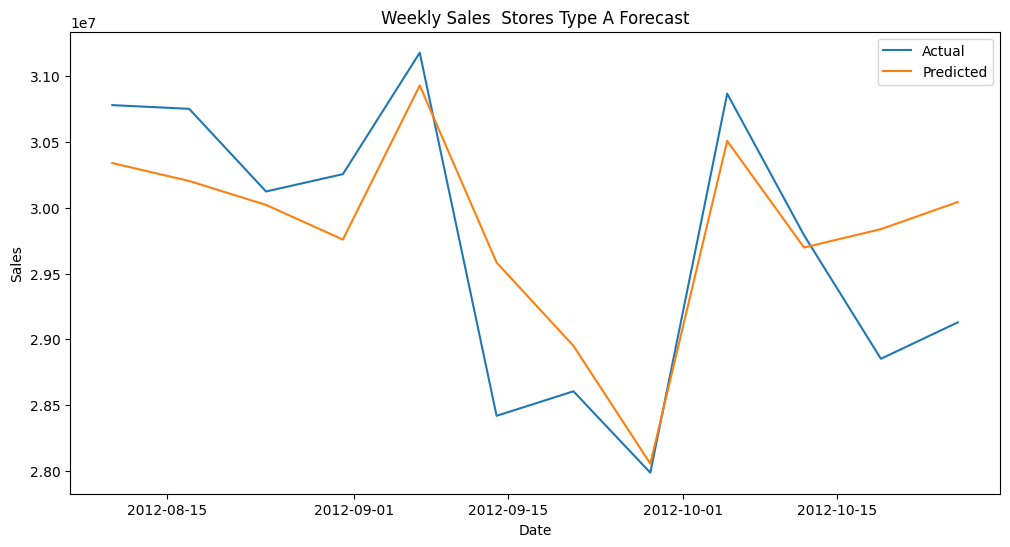

In [22]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index,y_pred, label='Predicted')
plt.title('Weekly Sales  Stores Type A Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [23]:
data1 = pd.DataFrame({
    'Weekly_Sales_Predicted': y_pred,
    'Weekly_Sales_Actual': y_test
})

In [24]:

feat_imp = pd.Series(grid_xgb_A.best_estimator_.feature_importances_, index=x_train.columns)

print(feat_imp.sort_values(ascending=False))

best_feature = feat_imp[feat_imp > 0.01].index

print(best_feature)


moving_avg          0.305138
month               0.171148
IsHoliday           0.119763
moving_max          0.072103
week                0.066426
moving_std          0.057364
Pre_Holiday_Week    0.051359
lag5                0.029709
lag1                0.027296
scales_change       0.021456
lag2                0.019526
lag4                0.013700
lag6                0.012309
moving_median       0.010942
lag3                0.008060
moving_min          0.007119
lag7                0.006581
moving_sum          0.000000
dtype: float32
Index(['IsHoliday', 'lag1', 'lag2', 'lag4', 'lag5', 'lag6', 'month', 'week',
       'scales_change', 'Pre_Holiday_Week', 'moving_avg', 'moving_median',
       'moving_std', 'moving_max'],
      dtype='object')


Weekly Sales Store Type B

In [25]:
x = df2.drop('Weekly_Sales_B',axis=1)
y = df2['Weekly_Sales_B']

x_train = x[:-12]
x_test = x[-12:]

y_train = y[:-12]
y_test = y[-12:]
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

par_xgb = {
    'learning_rate': [0.1, 0.2],
    'max_depth': [3, 4],
    'n_estimators': [100, 400],
    'subsample': [0.6, 0.8],
    'colsample_bytree': [0.6, 0.8],
    'gamma': [0, 0.1, 0.2],
    'reg_lambda': [1, 5],
    'min_child_weight': [2, 4]
}

xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
tscv = TimeSeriesSplit(n_splits=5)
grid_xgb_B = GridSearchCV(xgb, par_xgb, cv=tscv, n_jobs=-1, verbose=1,scoring='neg_mean_squared_error')
grid_xgb_B.fit(x_train, y_train)
print(grid_xgb_B.best_params_)
print(grid_xgb_B.best_score_)

y_pred = grid_xgb_B.predict(x_test)
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

(124, 18)
(12, 18)
(124,)
(12,)
Fitting 5 folds for each of 384 candidates, totalling 1920 fits
{'colsample_bytree': 0.8, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 4, 'min_child_weight': 2, 'n_estimators': 100, 'reg_lambda': 1, 'subsample': 0.6}
-3054331687427.672
199900223781.1588
0.14760510703695684


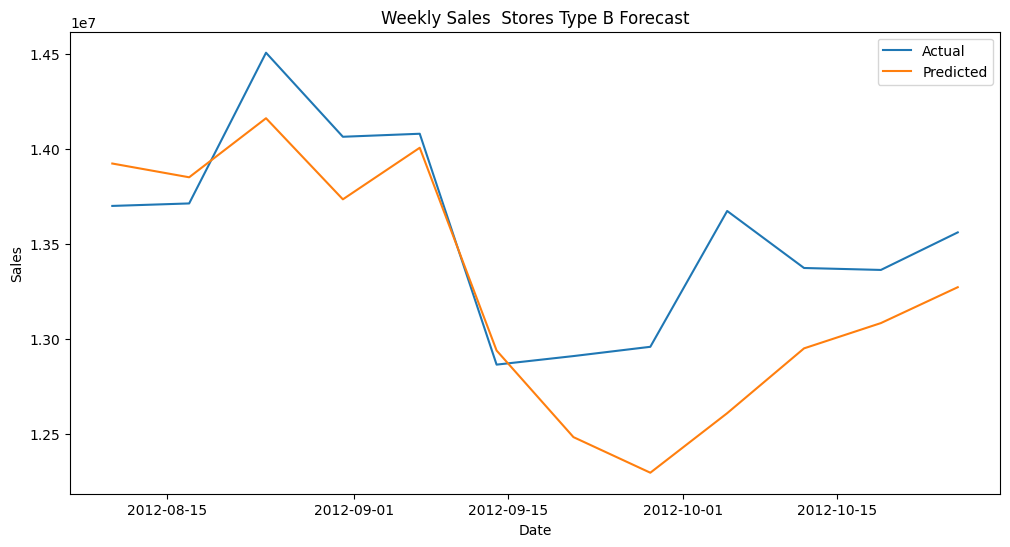

In [26]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index,y_pred, label='Predicted')
plt.title('Weekly Sales  Stores Type B Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [27]:
data2 = pd.DataFrame({
    'Weekly_Sales_Predicted': y_pred,
    'Weekly_Sales_Actual': y_test
})


In [28]:

feat_imp = pd.Series(grid_xgb_B.best_estimator_.feature_importances_, index=x_train.columns)

print(feat_imp.sort_values(ascending=False))

best_feature = feat_imp[feat_imp > 0.01].index

print(best_feature)


month               0.221140
moving_sum          0.194492
moving_avg          0.170861
lag7                0.055808
lag1                0.050667
moving_std          0.047148
IsHoliday           0.045230
lag5                0.042104
lag2                0.040446
lag3                0.036811
moving_median       0.021787
moving_max          0.019263
lag6                0.017233
scales_change       0.010791
lag4                0.008294
week                0.008027
moving_min          0.005251
Pre_Holiday_Week    0.004649
dtype: float32
Index(['IsHoliday', 'lag1', 'lag2', 'lag3', 'lag5', 'lag6', 'lag7', 'month',
       'scales_change', 'moving_avg', 'moving_median', 'moving_std',
       'moving_max', 'moving_sum'],
      dtype='object')


Weekly Sales Store Type C

In [29]:
x = df3.drop('Weekly_Sales_C',axis=1)
y = df3['Weekly_Sales_C']

x_train = x[:-12]
x_test = x[-12:]

y_train = y[:-12]
y_test = y[-12:]
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)
par_xgb ={
    'learning_rate': [0.2,0.3,0.1],
    'max_depth': [3,2],
    'n_estimators': [100, 300,400],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0],
    'min_child_weight': [1, 2],
    'reg_lambda': [1, 5, 10],
    'gamma': [0, 0.1, 0.2]
}



xgb = XGBRegressor(objective='reg:squarederror', random_state=42)
tscv = TimeSeriesSplit(n_splits=5)
grid_xgb_c = GridSearchCV(xgb, par_xgb, cv=tscv, n_jobs=-1, verbose=1,scoring='neg_mean_squared_error')
grid_xgb_c.fit(x_train, y_train)
print(grid_xgb_c.best_params_)
print(grid_xgb_c.best_score_)

y_pred = grid_xgb_c.predict(x_test)
print(mean_squared_error(y_test, y_pred))
print(r2_score(y_test, y_pred))

(124, 18)
(12, 18)
(124,)
(12,)
Fitting 5 folds for each of 1296 candidates, totalling 6480 fits
{'colsample_bytree': 1.0, 'gamma': 0, 'learning_rate': 0.2, 'max_depth': 2, 'min_child_weight': 2, 'n_estimators': 100, 'reg_lambda': 1, 'subsample': 1.0}
-11013488160.262085
1628670447.8084993
0.7521950629324409


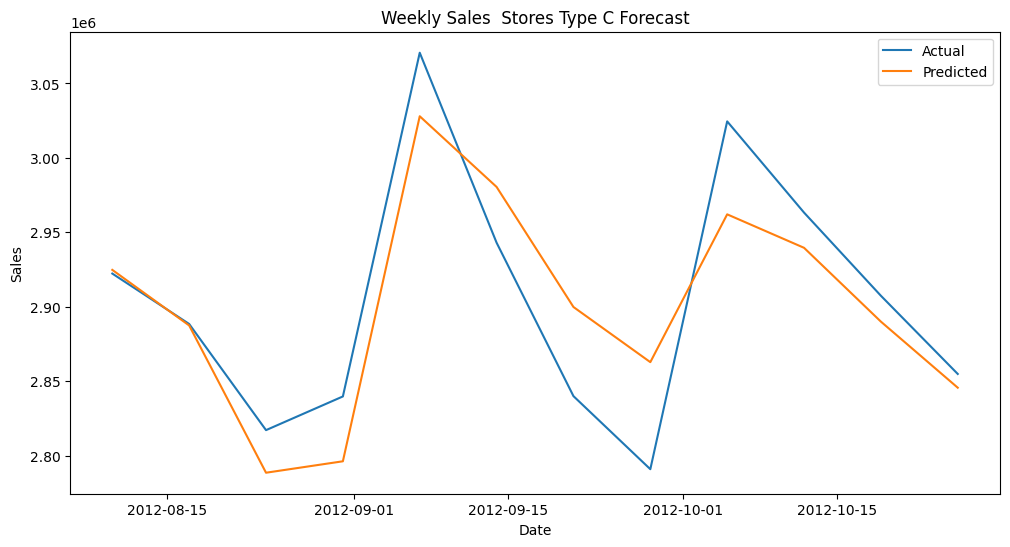

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index,y_pred, label='Predicted')
plt.title('Weekly Sales  Stores Type C Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [31]:
dat3 = pd.DataFrame({
    'Weekly_Sales_Predicted': y_pred,
    'Weekly_Sales_Actual': y_test
})

In [32]:

feat_imp = pd.Series(grid_xgb_c.best_estimator_.feature_importances_, index=x_train.columns)

print(feat_imp.sort_values(ascending=False))

best_feature = feat_imp[feat_imp > 0.01].index

print(best_feature)


lag4                0.432674
week                0.219950
moving_max          0.132396
IsHoliday           0.033311
moving_avg          0.032729
lag6                0.031724
lag1                0.020520
moving_min          0.016689
lag3                0.015497
moving_std          0.014361
scales_change       0.012783
lag2                0.011999
Pre_Holiday_Week    0.007691
month               0.007038
moving_median       0.006139
lag7                0.002716
lag5                0.001783
moving_sum          0.000000
dtype: float32
Index(['IsHoliday', 'lag1', 'lag2', 'lag3', 'lag4', 'lag6', 'week',
       'scales_change', 'moving_avg', 'moving_std', 'moving_max',
       'moving_min'],
      dtype='object')


In [33]:
import joblib
joblib.dump(grid_xgb_c, 'grid_xgb_c.pkl')
joblib.dump(grid_xgb_A, 'grid_xgb_A.pkl')

['grid_xgb_A.pkl']

In [34]:
import optuna
from xgboost import XGBRegressor
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

def objective(trial):
    params = {
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'n_estimators': trial.suggest_int('n_estimators', 500, 1500), 
        'subsample': trial.suggest_float('subsample', 0.5, 1.0),       
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-3, 10.0, log=True),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-3, 10.0, log=True),
        'gamma': trial.suggest_float('gamma', 0.1, 5),
        'random_state': 42,
        'n_jobs': -1
    }
    
    model = XGBRegressor(**params)
    tscv = TimeSeriesSplit(n_splits=5)
    
    score = cross_val_score(model, x_train, y_train, cv=tscv, scoring='neg_root_mean_squared_error').mean()
    
    return score

study = optuna.create_study(direction='maximize', sampler=optuna.samplers.TPESampler())
study.optimize(objective, n_trials=50)


c:\Users\kumar\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-05-07 04:25:51,767] A new study created in memory with name: no-name-d44e3dc6-175f-4c56-8b0a-28cb4acff126
[I 2026-05-07 04:25:53,447] Trial 0 finished with value: -109225.55037592349 and parameters: {'learning_rate': 0.04013957823423981, 'max_depth': 6, 'n_estimators': 567, 'subsample': 0.8549227012615018, 'colsample_bytree': 0.713405370089949, 'min_child_weight': 9, 'reg_lambda': 0.21187087318558281, 'reg_alpha': 0.03526747586446706, 'gamma': 0.8918292359381959}. Best is trial 0 with value: -109225.55037592349.
[I 2026-05-07 04:25:56,302] Trial 1 finished with value: -104431.99536831793 and parameters: {'learning_rate': 0.03934923074132329, 'max_depth': 10, 'n_estimators': 543, 'subsample': 0.87412547878

In [35]:
print(study.best_params)
print(study.best_value)

{'learning_rate': 0.014256884341144842, 'max_depth': 5, 'n_estimators': 1406, 'subsample': 0.5599526801538977, 'colsample_bytree': 0.8710134111001334, 'min_child_weight': 2, 'reg_lambda': 0.0027451841246819235, 'reg_alpha': 0.02081414353263323, 'gamma': 2.888870955824598}
-96485.85141651091


In [36]:
best_params = study.best_params

best_model = XGBRegressor(**best_params, random_state=42)

best_model.fit(x_train, y_train)

y_pred = best_model.predict(x_test)                               

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('RMSE:', rmse)
print('R2:', r2)

RMSE: 45858.47664178301
R2: 0.6800250452176142


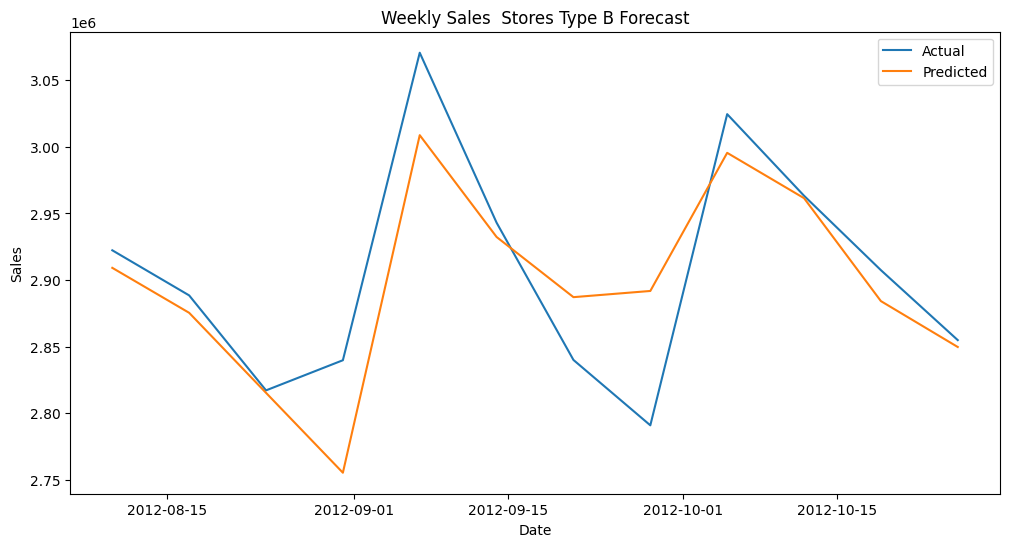

In [41]:
plt.figure(figsize=(12, 6))
plt.plot(y_test.index, y_test, label='Actual')
plt.plot(y_test.index,y_pred, label='Predicted')
plt.title('Weekly Sales  Stores Type B Forecast')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.show()

In [38]:
joblib.dump(best_model, 'xgb_B.pkl')

['xgb_B.pkl']

In [39]:
data2 = pd.DataFrame({
    'Weekly_Sales_Predicted': y_pred,
    'Weekly_Sales_Actual': y_test
})


In [40]:
data1.to_csv('prediction_store_A.csv')
data2.to_csv('prediction_store_B.csv')
dat3.to_csv('prediction_store_C.csv')